In [8]:
from agentlab.experiments.exp_utils import RESULTS_DIR
from agentlab.analyze import inspect_results
from agentlab.experiments.study import get_most_recent_study
from pathlib import Path

### Load results
find the most recent study and load all summary information in a result dataframe.

The summary information contains the configuration of the environment, and the agents and various statistics about the experiment. It doesn't contain the details about the episode such as DOM or AXTree for faster loading.

In [9]:
RESULTS_DIR


PosixPath('tutorials/ipazia/results')

In [10]:
# replace this by your desired directory if needed.
RESULTS_DIR = Path("results")
result_dir = get_most_recent_study(RESULTS_DIR, contains=None)

print(result_dir)
result_df = inspect_results.load_result_df(result_dir)

results/2026-01-14_17-14-58_genericagent-google-gemini-3-flash-preview-on-workarena-l2-agent-curriculum-eval


Loading results:   0%|          | 0/2 [00:00<?, ?it/s]

Loading results: 100%|██████████| 2/2 [00:01<00:00,  1.37it/s]


In [11]:
report = inspect_results.global_report(result_df)
inspect_results.display_report(report)

Found multiple configuration, averaging across tasks and returning a per-agent report.


,agent.agent name,env.benchmark,avg reward,std err,avg steps,n completed,n err,cum cost
0,GenericAgent-google_gemini-3-flash-preview,workarena,1,0,17.5,2/2,0,0.1758


### Print error report if any

In [12]:
inspect_results.error_report(result_df, max_stack_trace=2, use_log=True)

''

### Loading an Episode

action: fill('221', 'Problem')
reward: 0
AXTree: RootWebArea 'Shared admin dashboard | ServiceNow', focused
	[47] generic, live='assertive', atomic, relevant='additions text'
	[48] generic, live='polite', atomic, relevant='additions text'
	[53] generic, live='polite', atomic, relevant='all'
	[56] navigation 'Global skip links', visible
		[57] link 'Skip to main content', clickable
		[58] link 'Open accessibility preferences', clickable
	[59] generic, live='polite', atomic, relevant='additions text'
	[62] navigation 'Primary', visible
		navigat
screenshot type: <class 'numpy.ndarray'>


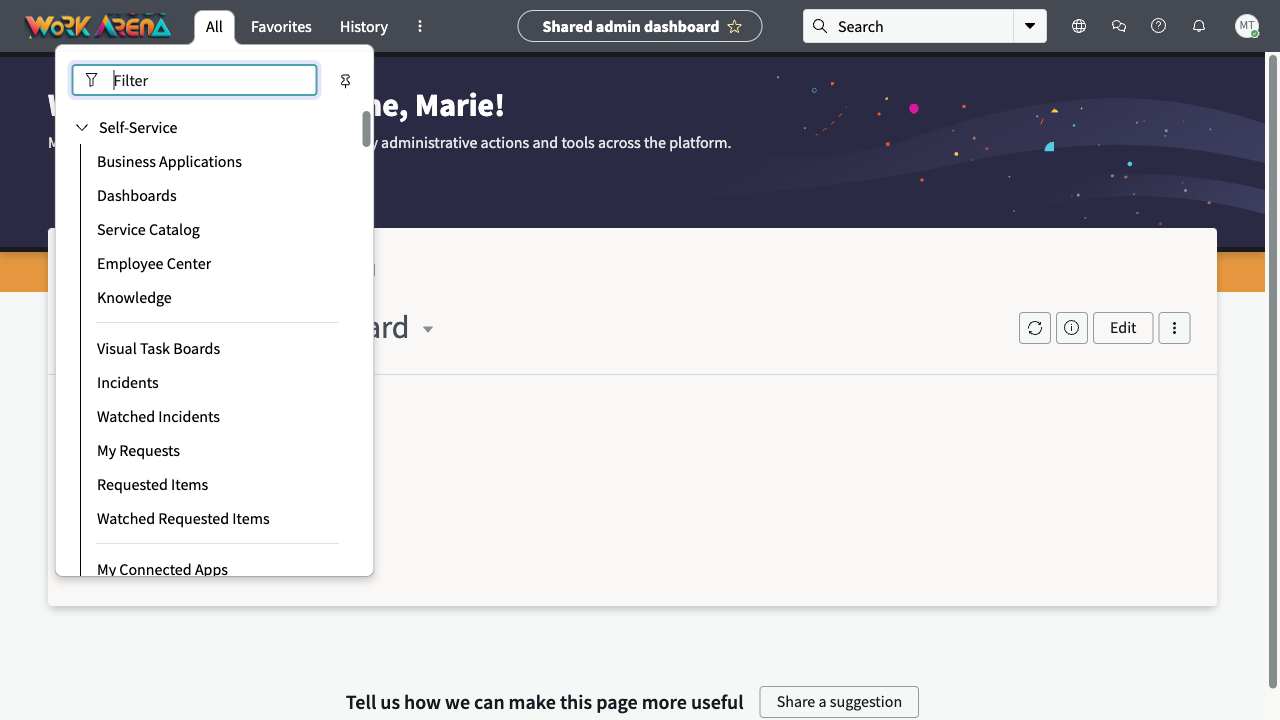

In [13]:
from agentlab.experiments.loop import ExpResult

# lazy loader for all the information of on experiment (1 agent on 1 task)
result = ExpResult(result_df.iloc[0].exp_dir)

episode = result.steps_info
print(f"action: {episode[1].action}")
print(f"reward: {episode[1].reward}")
print(f"AXTree: {episode[1].obs['axtree_txt'][:500]}")

# formatted as an array
print(f"screenshot type: {type(episode[1].obs['screenshot'])}")

# loading from png
display(result.get_screenshot(1))

### list keys in the observations dict

In [14]:
import json

keys_str = '\n  '.join(list(episode[1].obs.keys()))
print(f"Obs Keys: {keys_str}")

Obs Keys: chat_messages
  goal
  goal_object
  open_pages_urls
  open_pages_titles
  active_page_index
  url
  dom_object
  axtree_object
  extra_element_properties
  focused_element_bid
  last_action
  last_action_error
  elapsed_time
  dom_txt
  axtree_txt
  pruned_html
  screenshot


## extra_elements_properties
contains a dictionnary for the bounding box and visible properties of each elements in the page

In [15]:
extra_properties = json.dumps(episode[1].obs["extra_element_properties"], indent=2)
print(extra_properties)

{
  "0": {
    "visibility": 1.0,
    "bbox": [
      0.0,
      0.0,
      2560.0,
      1440.0
    ],
    "clickable": false,
    "set_of_marks": false
  },
  "1": {
    "visibility": 0.0,
    "bbox": null,
    "clickable": false,
    "set_of_marks": false
  },
  "2": {
    "visibility": 0.0,
    "bbox": null,
    "clickable": false,
    "set_of_marks": false
  },
  "3": {
    "visibility": 0.0,
    "bbox": null,
    "clickable": false,
    "set_of_marks": false
  },
  "4": {
    "visibility": 0.0,
    "bbox": null,
    "clickable": false,
    "set_of_marks": false
  },
  "5": {
    "visibility": 0.0,
    "bbox": null,
    "clickable": false,
    "set_of_marks": false
  },
  "6": {
    "visibility": 0.0,
    "bbox": null,
    "clickable": false,
    "set_of_marks": false
  },
  "7": {
    "visibility": 0.0,
    "bbox": null,
    "clickable": false,
    "set_of_marks": false
  },
  "8": {
    "visibility": 0.0,
    "bbox": null,
    "clickable": false,
    "set_of_marks": false
  },
 